# Bird Species–Province Relationships with Environmental Features

This notebook categorizes bird observations by **verbatimScientificName** and **stateProvince**, then analyzes their relationships with **temperature (temp_mean)** and other environmental features.

## Goals
1. Standardize and encode species and province categorical variables
2. Explore distributions and coverage of species–province combinations
3. Analyze temperature variation by species and province
4. Test for statistical significance of group differences
5. Model temperature using species and province as predictors
6. Identify top drivers of temperature relationships

## Section 1: Load Dataset and Select Analysis Columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import f_oneway, kruskal, spearmanr, pearsonr
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')

# Configure visualization
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Load dataset
df = pd.read_csv('../file6.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names:\n{df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (1552048, 24)

Column names:
['index', 'verbatimScientificName', 'stateProvince', 'individualCount', 'decimalLatitude', 'decimalLongitude', 'eventDate', 'avg_rad', 'NDVI_raw', 'LandCover_Class', 'elevation_meters', 'Carbon_Mass', 'Dust_Mass', 'SO2_Mass', 'Sulfate_Mass', 'Sea_Salt_Mass', 'Total_Aerosol_Extinction', 'temp_mean', 'rainfall', 'wind_mean', 'humid_mean', 'shortwave_radiation', 'lka_general_2020', 'NDVI']

First few rows:


,index,verbatimScientificName,stateProvince,individualCount,decimalLatitude,decimalLongitude,eventDate,avg_rad,NDVI_raw,LandCover_Class,...,Sulfate_Mass,Sea_Salt_Mass,Total_Aerosol_Extinction,temp_mean,rainfall,wind_mean,humid_mean,shortwave_radiation,lka_general_2020,NDVI
0,0,Anarhynchus alexandrinus,Mannar,8.0,9.058512,79.85502,2021-01-06,0.66,3792.0,10,...,3.372161e-09,3.725563e-08,0.175115,26.58,15.17,1.31,85.53,17.65,2.805795,0.3792
1,2,Hirundo rustica,Colombo,10.0,6.866285,79.93144,2024-12-23,10.16,7045.0,13,...,4.424376e-09,3.249729e-08,0.198127,26.21,0.25,2.51,84.30,20.49,8.917330,0.7045
2,6,Corvus macrorhynchos,Matara,2.0,5.983496,80.52548,2024-10-12,1.26,6989.0,10,...,7.456183e-10,5.362027e-08,0.131458,26.91,14.47,5.18,83.81,15.67,2.768103,0.6989
3,7,Dicrurus caerulescens,Matale,1.0,7.969125,80.75477,2021-11-20,0.37,8543.0,8,...,1.612494e-09,3.017664e-08,0.123156,25.30,2.54,2.98,89.54,21.99,3.339740,0.8543
4,8,Threskiornis melanocephalus,Jaffna,30.0,9.637712,79.95190,2019-03-25,0.52,4000.0,10,...,2.737918e-09,3.224930e-08,0.220155,29.67,0.00,4.65,63.33,24.53,3.209018,0.4000


In [2]:
# Select core columns for analysis
core_cols = ['verbatimScientificName', 'stateProvince', 'temp_mean', 'rainfall', 
             'wind_mean', 'humid_mean', 'elevation_meters', 'NDVI_raw', 
             'LandCover_Class', 'individualCount', 'eventDate']

# Check for columns that exist
available_cols = [c for c in core_cols if c in df.columns]
missing_cols = [c for c in core_cols if c not in df.columns]

print(f"Available columns: {len(available_cols)}")
print(f"Missing columns: {missing_cols if missing_cols else 'None'}\n")

# Select available columns
df_work = df[available_cols].copy()

# Data quality report
print("Missingness Report:")
print(df_work.isnull().sum())
print(f"\nBasic statistics for temp_mean:")
print(df_work['temp_mean'].describe())

Available columns: 11
Missing columns: None

Missingness Report:
verbatimScientificName    0
stateProvince             0
temp_mean                 0
rainfall                  0
wind_mean                 0
humid_mean                0
elevation_meters          0
NDVI_raw                  0
LandCover_Class           0
individualCount           0
eventDate                 0
dtype: int64

Basic statistics for temp_mean:
count    1.552048e+06
mean     2.607071e+01
std      1.796483e+00
min      1.808000e+01
25%      2.509000e+01
50%      2.637000e+01
75%      2.726000e+01
max      3.246000e+01
Name: temp_mean, dtype: float64


## Section 2: Clean and Standardize `verbatimScientificName` and `stateProvince`

In [3]:
# Clean verbatimScientificName
df_work['species_clean'] = (df_work['verbatimScientificName']
                            .str.strip()  # Remove leading/trailing whitespace
                            .str.title()  # Standardize capitalization
                            .fillna('Unknown'))

# Clean stateProvince
df_work['province_clean'] = (df_work['stateProvince']
                             .str.strip()
                             .str.title()
                             .fillna('Unknown'))

# Report unique values
print(f"Unique species (original): {df_work['verbatimScientificName'].nunique()}")
print(f"Unique species (cleaned): {df_work['species_clean'].nunique()}")
print(f"\nUnique provinces (original): {df_work['stateProvince'].nunique()}")
print(f"Unique provinces (cleaned): {df_work['province_clean'].nunique()}")

# Map rare species/provinces to 'Other' with frequency threshold
species_freq = df_work['species_clean'].value_counts()
province_freq = df_work['province_clean'].value_counts()

# Keep species/provinces with at least 50 observations
species_threshold = 50
province_threshold = 30

print(f"\nSpecies with >= {species_threshold} observations: {(species_freq >= species_threshold).sum()}")
print(f"Provinces with >= {province_threshold} observations: {(province_freq >= province_threshold).sum()}")

# Create collapsed categories
df_work['species_grouped'] = df_work['species_clean'].apply(
    lambda x: x if species_freq.get(x, 0) >= species_threshold else 'Other'
)
df_work['province_grouped'] = df_work['province_clean'].apply(
    lambda x: x if province_freq.get(x, 0) >= province_threshold else 'Other'
)

print(f"\nSpecies after grouping: {df_work['species_grouped'].nunique()}")
print(f"Provinces after grouping: {df_work['province_grouped'].nunique()}")

Unique species (original): 429
Unique species (cleaned): 429

Unique provinces (original): 25
Unique provinces (cleaned): 25

Species with >= 50 observations: 330
Provinces with >= 30 observations: 25

Species after grouping: 331
Provinces after grouping: 25


## Section 3: Create Categorical Encodings for Species and Province

In [4]:
# Convert to categorical type
df_work['species_grouped'] = df_work['species_grouped'].astype('category')
df_work['province_grouped'] = df_work['province_grouped'].astype('category')

# Label encoding (integer codes for statistical tests)
le_species = LabelEncoder()
le_province = LabelEncoder()

df_work['species_code'] = le_species.fit_transform(df_work['species_grouped'])
df_work['province_code'] = le_province.fit_transform(df_work['province_grouped'])

# Create interaction feature
df_work['species_province'] = (df_work['species_grouped'].astype(str) + ' / ' + 
                                df_work['province_grouped'].astype(str))

# One-hot encoding for regression
species_dummies = pd.get_dummies(df_work['species_grouped'], prefix='species', drop_first=True)
province_dummies = pd.get_dummies(df_work['province_grouped'], prefix='province', drop_first=True)

df_encoded = pd.concat([df_work, species_dummies, province_dummies], axis=1)

print("Label encoding mapping:")
print("\nSpecies codes:")
for idx, label in enumerate(le_species.classes_):
    print(f"  {idx}: {label}")

print("\nProvince codes:")
for idx, label in enumerate(le_province.classes_):
    print(f"  {idx}: {label}")

print(f"\nEncoded dataframe shape: {df_encoded.shape}")
print(f"Species dummies: {species_dummies.shape[1]} columns")
print(f"Province dummies: {province_dummies.shape[1]} columns")

Label encoding mapping:

Species codes:
  0: Acridotheres Tristis
  1: Acritillas Indica
  2: Acrocephalus Dumetorum
  3: Acrocephalus Stentoreus
  4: Actitis Hypoleucos
  5: Aegithina Nigrolutea
  6: Aegithina Tiphia
  7: Aerodramus Unicolor
  8: Alauda Gulgula
  9: Alcedo Atthis
  10: Amaurornis Phoenicurus
  11: Anarhynchus Alexandrinus
  12: Anarhynchus Atrifrons
  13: Anarhynchus Leschenaultii
  14: Anas Acuta
  15: Anas Crecca
  16: Anas Poecilorhyncha
  17: Anastomus Oscitans
  18: Anhinga Melanogaster
  19: Anthracoceros Coronatus
  20: Anthus Cervinus
  21: Anthus Godlewskii
  22: Anthus Richardi
  23: Anthus Rufulus
  24: Apus Affinis
  25: Ardea Alba
  26: Ardea Cinerea
  27: Ardea Coromanda
  28: Ardea Intermedia
  29: Ardea Purpurea
  30: Ardenna Pacifica
  31: Ardeola Grayii
  32: Arenaria Interpres
  33: Argya Affinis
  34: Argya Cinereifrons
  35: Argya Rufescens
  36: Artamus Fuscus
  37: Aviceda Jerdoni
  38: Batrachostomus Moniliger
  39: Botaurus Cinnamomeus
  40: B

## Section 4: Exploratory Profiles of Species–Province Combinations

In [5]:
# Species and province frequency
print("=== SPECIES DISTRIBUTION ===")
species_counts = df_work['species_grouped'].value_counts()
print(species_counts.head(15))
print(f"\nTotal species: {len(species_counts)}")

print("\n=== PROVINCE DISTRIBUTION ===")
province_counts = df_work['province_grouped'].value_counts()
print(province_counts)

# Species-Province combinations
print("\n=== SPECIES-PROVINCE COMBINATIONS ===")
sp_counts = df_work.groupby(['species_grouped', 'province_grouped']).size().reset_index(name='count')
print(f"Total unique combinations: {len(sp_counts)}")
print(f"\nTop 20 combinations:")
print(sp_counts.nlargest(20, 'count'))

# Coverage analysis
print(f"\nCombinations with >= 50 observations: {(sp_counts['count'] >= 50).sum()}")
print(f"Combinations with >= 100 observations: {(sp_counts['count'] >= 100).sum()}")
print(f"Combinations with >= 500 observations: {(sp_counts['count'] >= 500).sum()}")

=== SPECIES DISTRIBUTION ===
species_grouped
Pycnonotus Cafer         43378
Spilopelia Chinensis     41311
Acridotheres Tristis     36738
Psittacula Krameri       32501
Halcyon Smyrnensis       32413
Argya Affinis            31034
Psilopogon Zeylanicus    29419
Orthotomus Sutorius      29269
Corvus Splendens         29264
Leptocoma Zeylonica      26849
Copsychus Saularis       25930
Eudynamys Scolopaceus    25710
Oriolus Xanthornus       25569
Ardeola Grayii           23296
Dicrurus Caerulescens    23132
Name: count, dtype: int64

Total species: 331

=== PROVINCE DISTRIBUTION ===
province_grouped
Colombo         289337
Gampaha         179526
Hambantota      161216
Matara          123577
Ratnapura       116834
Monaragala       68731
Mannar           63446
Galle            59162
Nuwara           57376
Kegalla          57108
Matale           52327
Kalutara         49765
Puttalam         44845
Anuradhapura     44755
Badulla          43420
Kandy            38433
Kurunegala       36438
Jaffn

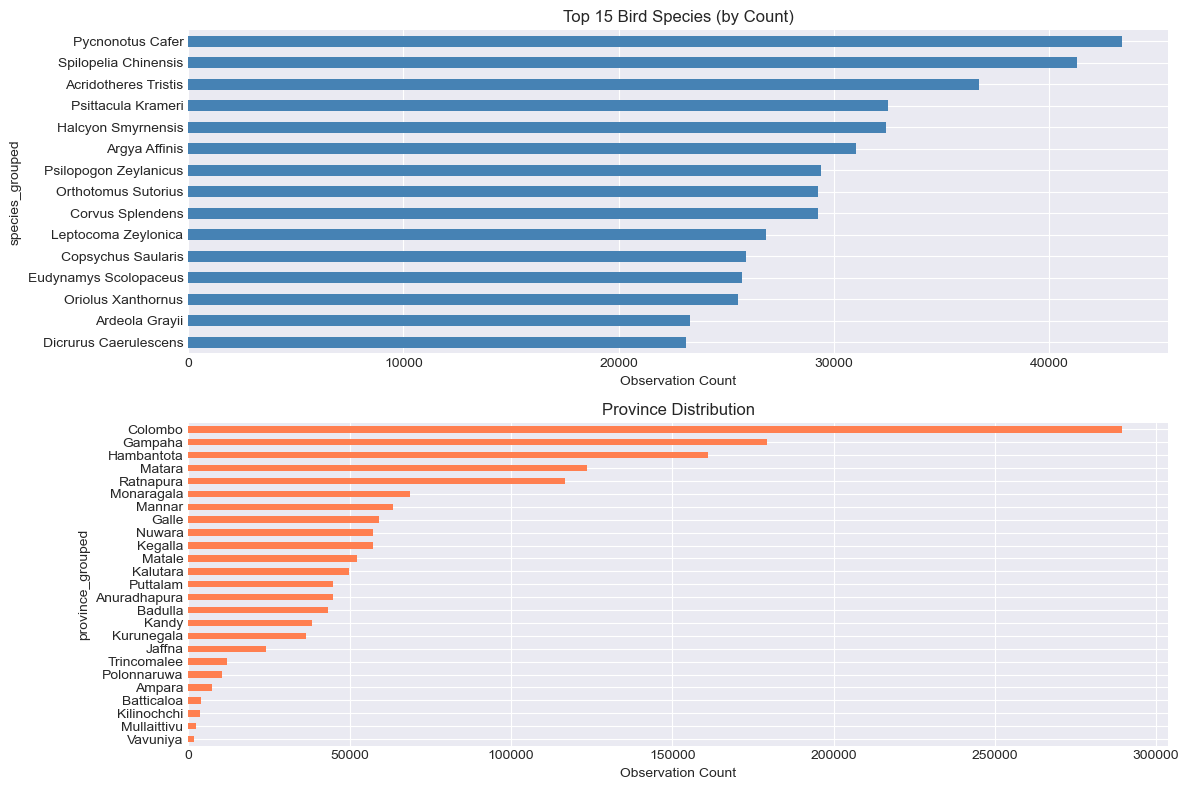

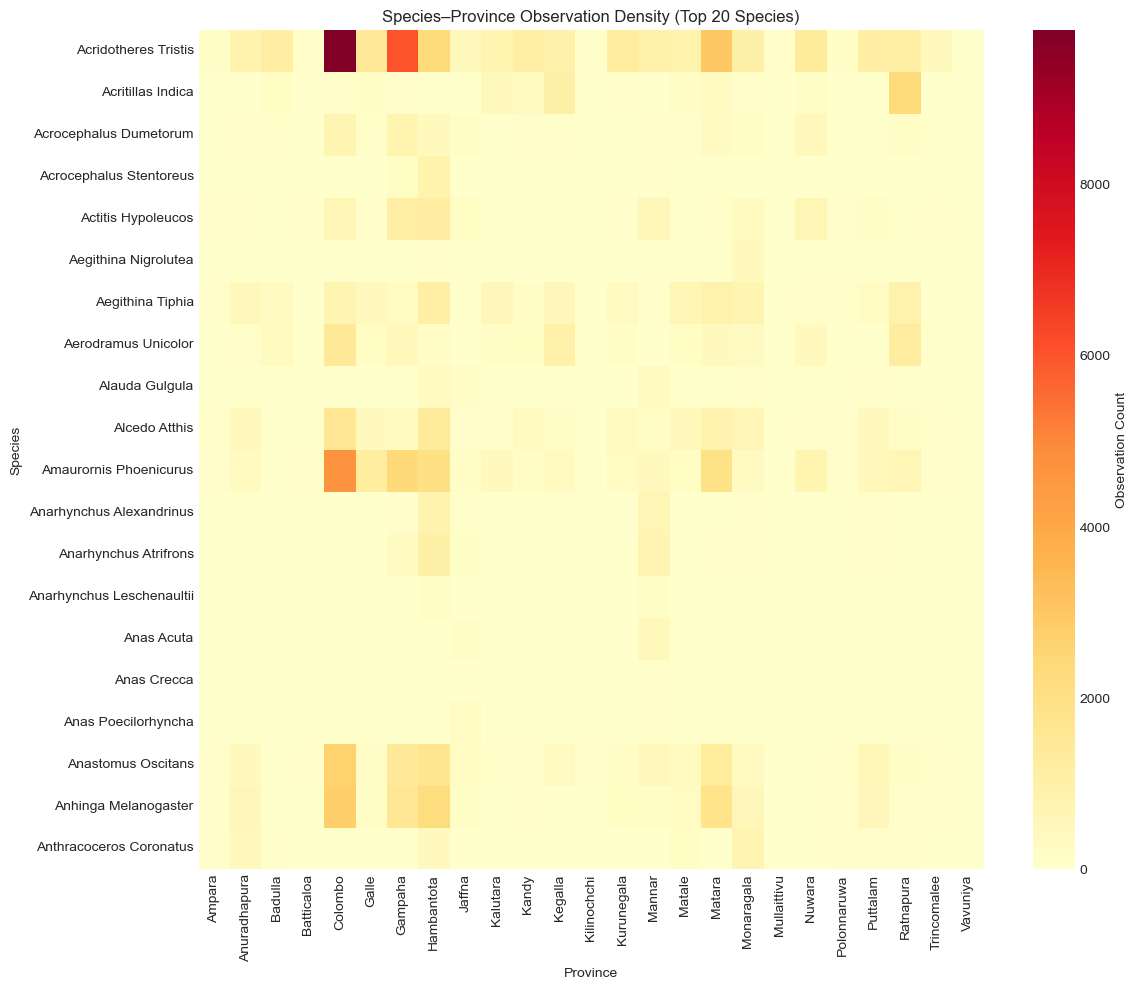

In [6]:
# Visualize top species and provinces
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Top species
ax1 = axes[0]
species_counts.head(15).plot(kind='barh', ax=ax1, color='steelblue')
ax1.set_xlabel('Observation Count')
ax1.set_title('Top 15 Bird Species (by Count)')
ax1.invert_yaxis()

# Top provinces
ax2 = axes[1]
province_counts.plot(kind='barh', ax=ax2, color='coral')
ax2.set_xlabel('Observation Count')
ax2.set_title('Province Distribution')
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# Heatmap of species-province combinations
sp_pivot = sp_counts.pivot_table(index='species_grouped', 
                                  columns='province_grouped', 
                                  values='count', 
                                  fill_value=0)

# Only show species and provinces with sufficient data for readability
sp_pivot_filtered = sp_pivot.iloc[:20, :]  # Top 20 species

plt.figure(figsize=(12, 10))
sns.heatmap(sp_pivot_filtered, annot=False, cmap='YlOrRd', cbar_kws={'label': 'Observation Count'})
plt.title('Species–Province Observation Density (Top 20 Species)')
plt.xlabel('Province')
plt.ylabel('Species')
plt.tight_layout()
plt.show()

## Section 5: Analyze `temp_mean` by Species, Province, and Their Interaction

In [7]:
# Remove rows with missing temp_mean
df_analysis = df_work.dropna(subset=['temp_mean']).copy()
print(f"Rows with temp_mean data: {len(df_analysis)}")

# Temperature statistics by species
print("\n=== TEMPERATURE BY SPECIES ===")
temp_by_species = df_analysis.groupby('species_grouped')['temp_mean'].agg(['mean', 'median', 'std', 'count'])
temp_by_species = temp_by_species.sort_values('mean', ascending=False)
print(temp_by_species)

# Temperature statistics by province
print("\n=== TEMPERATURE BY PROVINCE ===")
temp_by_province = df_analysis.groupby('province_grouped')['temp_mean'].agg(['mean', 'median', 'std', 'count'])
temp_by_province = temp_by_province.sort_values('mean', ascending=False)
print(temp_by_province)

# Temperature statistics by species-province combination
print("\n=== TEMPERATURE BY SPECIES-PROVINCE (Top 20) ===")
temp_by_sp = df_analysis.groupby(['species_grouped', 'province_grouped'])['temp_mean'].agg(['mean', 'median', 'std', 'count'])
temp_by_sp = temp_by_sp.sort_values('count', ascending=False)
print(temp_by_sp.head(20))

Rows with temp_mean data: 1552048

=== TEMPERATURE BY SPECIES ===
                            mean  median       std  count
species_grouped                                          
Merops Persicus        28.054921  27.720  0.676430     63
Ardenna Pacifica       27.528649  27.520  1.282990     74
Haematopus Ostralegus  27.482340  27.210  1.706933     94
Onychoprion Fuscatus   27.404259  27.265  1.115660     54
Pseudibis Papillosa    27.310400  27.590  1.481837     50
...                          ...     ...       ...    ...
Turdus Simillimus      22.660385  22.650  1.473934    935
Elaphrornis Palliseri  22.484305  22.480  1.332139    741
Saxicola Caprata       22.449080  22.530  1.400409   1011
Ficedula Subrubra      22.403026  22.470  1.206870    899
Geokichla Wardii       22.268630  22.380  1.180939    686

[331 rows x 4 columns]

=== TEMPERATURE BY PROVINCE ===
                       mean  median       std   count
province_grouped                                     
Mullaittivu    

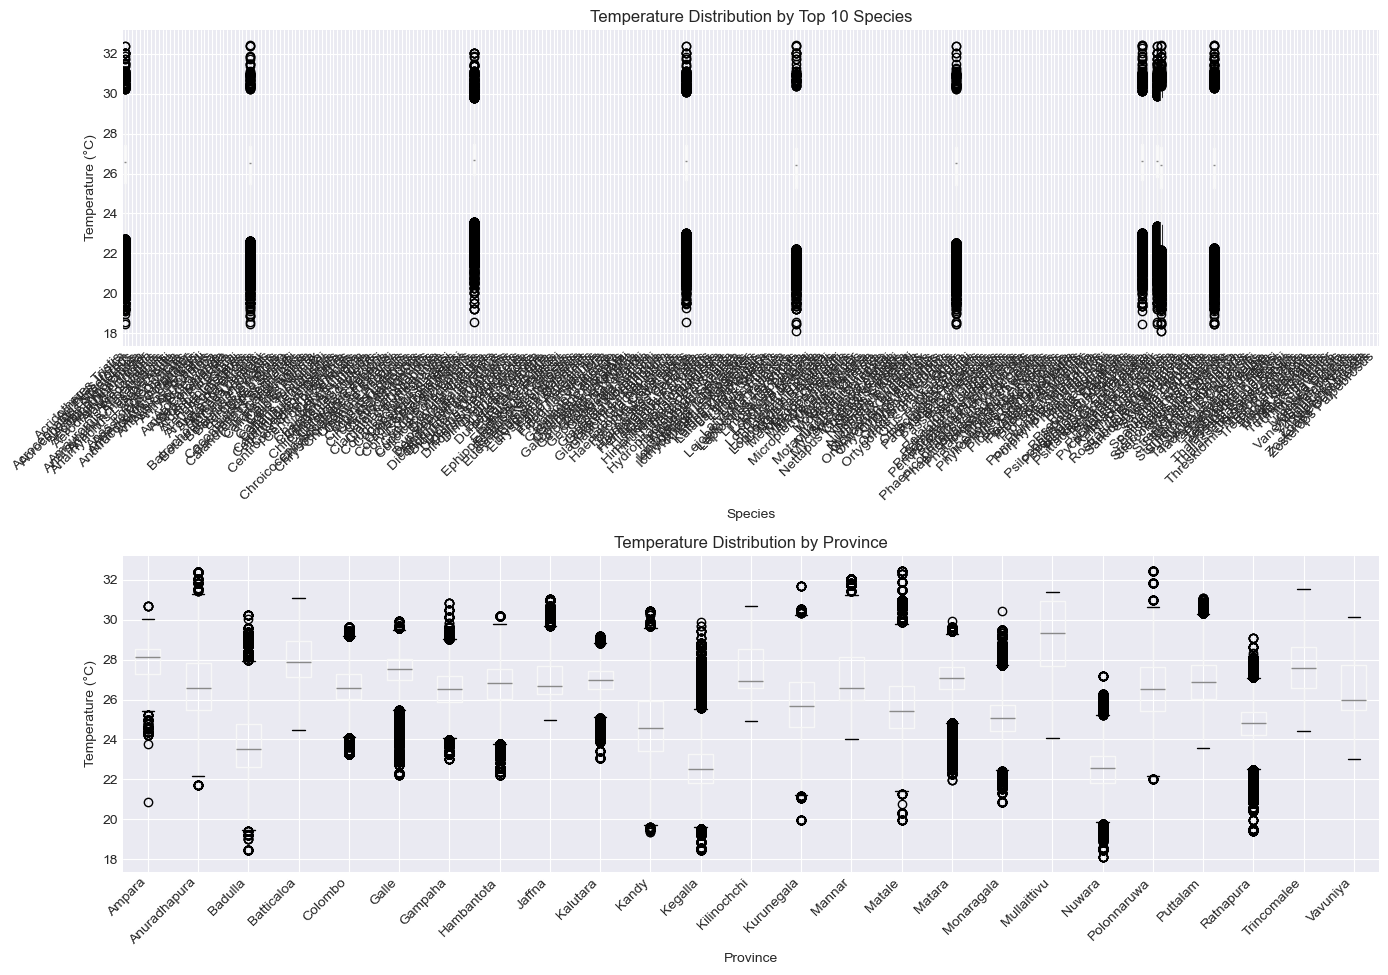

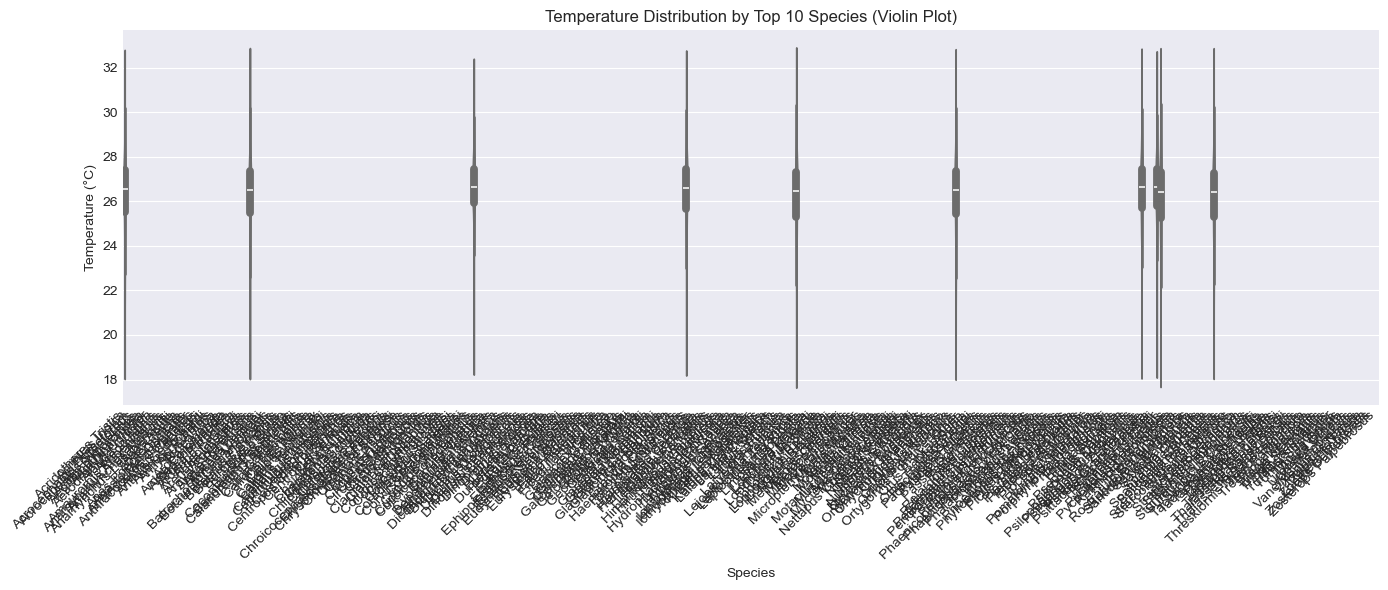

In [8]:
# Boxplot: Temperature by Species (top 10)
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

top_species = species_counts.head(10).index.tolist()
df_top_species = df_analysis[df_analysis['species_grouped'].isin(top_species)]

ax1 = axes[0]
df_top_species.boxplot(column='temp_mean', by='species_grouped', ax=ax1)
ax1.set_xlabel('Species')
ax1.set_ylabel('Temperature (°C)')
ax1.set_title('Temperature Distribution by Top 10 Species')
plt.sca(ax1)
plt.xticks(rotation=45, ha='right')

# Boxplot: Temperature by Province
ax2 = axes[1]
df_analysis.boxplot(column='temp_mean', by='province_grouped', ax=ax2)
ax2.set_xlabel('Province')
ax2.set_ylabel('Temperature (°C)')
ax2.set_title('Temperature Distribution by Province')
plt.sca(ax2)
plt.xticks(rotation=45, ha='right')

plt.suptitle('')  # Remove automatic title
plt.tight_layout()
plt.show()

# Violin plots for top species
fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=df_top_species, x='species_grouped', y='temp_mean', ax=ax)
ax.set_xlabel('Species')
ax.set_ylabel('Temperature (°C)')
ax.set_title('Temperature Distribution by Top 10 Species (Violin Plot)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Section 6: Statistical Tests for Group Differences in `temp_mean`

In [9]:
# Test for normality and homogeneity of variance
from scipy.stats import levene, shapiro

print("=== NORMALITY TEST (Shapiro-Wilk on sample) ===")
sample_temp = df_analysis['temp_mean'].sample(min(5000, len(df_analysis)), random_state=42)
stat, p_normality = shapiro(sample_temp)
print(f"Shapiro-Wilk test: statistic={stat:.4f}, p-value={p_normality:.4e}")
print(f"Normally distributed: {'Yes' if p_normality > 0.05 else 'No (likely due to large sample size)'}")

# Test homogeneity of variance across species
species_groups = [group['temp_mean'].dropna().values for name, group in df_analysis.groupby('species_grouped')]
stat_levene, p_levene = levene(*species_groups)
print(f"\n=== LEVENE'S TEST (Species homogeneity) ===")
print(f"Levene's test: statistic={stat_levene:.4f}, p-value={p_levene:.4e}")
print(f"Equal variance: {'Yes' if p_levene > 0.05 else 'No'}")

# One-way ANOVA for species effect
print("\n=== ONE-WAY ANOVA: SPECIES EFFECT ON TEMPERATURE ===")
groups_species = [group['temp_mean'].dropna().values for name, group in df_analysis.groupby('species_grouped')]
f_stat_species, p_anova_species = f_oneway(*groups_species)
print(f"F-statistic: {f_stat_species:.4f}")
print(f"P-value: {p_anova_species:.4e}")
print(f"Significant (α=0.05): {'Yes' if p_anova_species < 0.05 else 'No'}")

# Kruskal-Wallis test (non-parametric alternative)
print("\n=== KRUSKAL-WALLIS TEST: SPECIES EFFECT (Non-parametric) ===")
h_stat_species, p_kw_species = kruskal(*groups_species)
print(f"H-statistic: {h_stat_species:.4f}")
print(f"P-value: {p_kw_species:.4e}")
print(f"Significant (α=0.05): {'Yes' if p_kw_species < 0.05 else 'No'}")

# One-way ANOVA for province effect
print("\n=== ONE-WAY ANOVA: PROVINCE EFFECT ON TEMPERATURE ===")
groups_province = [group['temp_mean'].dropna().values for name, group in df_analysis.groupby('province_grouped')]
f_stat_province, p_anova_province = f_oneway(*groups_province)
print(f"F-statistic: {f_stat_province:.4f}")
print(f"P-value: {p_anova_province:.4e}")
print(f"Significant (α=0.05): {'Yes' if p_anova_province < 0.05 else 'No'}")

# Kruskal-Wallis for province
print("\n=== KRUSKAL-WALLIS TEST: PROVINCE EFFECT (Non-parametric) ===")
h_stat_province, p_kw_province = kruskal(*groups_province)
print(f"H-statistic: {h_stat_province:.4f}")
print(f"P-value: {p_kw_province:.4e}")
print(f"Significant (α=0.05): {'Yes' if p_kw_province < 0.05 else 'No'}")

=== NORMALITY TEST (Shapiro-Wilk on sample) ===
Shapiro-Wilk test: statistic=0.9685, p-value=9.3922e-32
Normally distributed: No (likely due to large sample size)

=== LEVENE'S TEST (Species homogeneity) ===
Levene's test: statistic=168.6521, p-value=0.0000e+00
Equal variance: No

=== ONE-WAY ANOVA: SPECIES EFFECT ON TEMPERATURE ===
F-statistic: 930.0021
P-value: 0.0000e+00
Significant (α=0.05): Yes

=== KRUSKAL-WALLIS TEST: SPECIES EFFECT (Non-parametric) ===
H-statistic: 212178.1000
P-value: 0.0000e+00
Significant (α=0.05): Yes

=== ONE-WAY ANOVA: PROVINCE EFFECT ON TEMPERATURE ===
F-statistic: 72781.9204
P-value: 0.0000e+00
Significant (α=0.05): Yes

=== KRUSKAL-WALLIS TEST: PROVINCE EFFECT (Non-parametric) ===
H-statistic: 676975.2691
P-value: 0.0000e+00
Significant (α=0.05): Yes


## Section 7: Model `temp_mean` Using Categorical Predictors

In [ ]:
# Prepare data for modeling
df_model = df_analysis.dropna(subset=['temp_mean']).copy()

# Use one-hot encoded dummies
species_dummies = pd.get_dummies(df_model['species_grouped'], prefix='species', drop_first=True)
province_dummies = pd.get_dummies(df_model['province_grouped'], prefix='province', drop_first=True)

X = pd.concat([species_dummies, province_dummies], axis=1)
y = df_model['temp_mean'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Target variable (temp_mean) shape: {y.shape}")
print(f"\nFeature names (first 10):")
print(X.columns.tolist()[:10])

# Linear Regression
print("\n=== LINEAR REGRESSION MODEL ===")
lr_model = LinearRegression()

# Cross-validation scores
cv_scores_lr = cross_validate(lr_model, X, y, cv=5, 
                               scoring=['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'])

print(f"R² Score (CV mean): {cv_scores_lr['test_r2'].mean():.4f} (+/- {cv_scores_lr['test_r2'].std():.4f})")
print(f"RMSE (CV mean): {np.sqrt(-cv_scores_lr['test_neg_mean_squared_error'].mean()):.4f}")
print(f"MAE (CV mean): {-cv_scores_lr['test_neg_mean_absolute_error'].mean():.4f}")

# Fit on full data for interpretation
lr_model.fit(X, y)
y_pred_lr = lr_model.predict(X)
r2_lr = 1 - np.sum((y - y_pred_lr)**2) / np.sum((y - np.mean(y))**2)
rmse_lr = np.sqrt(np.mean((y - y_pred_lr)**2))
mae_lr = np.mean(np.abs(y - y_pred_lr))

print(f"\nFull data R²: {r2_lr:.4f}")
print(f"Full data RMSE: {rmse_lr:.4f}")
print(f"Full data MAE: {mae_lr:.4f}")

# Random Forest Model (for feature importance without linear assumption)
print("\n=== RANDOM FOREST MODEL ===")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)

cv_scores_rf = cross_validate(rf_model, X, y, cv=5, 
                               scoring=['r2', 'neg_mean_squared_error', 'neg_mean_absolute_error'])

print(f"R² Score (CV mean): {cv_scores_rf['test_r2'].mean():.4f} (+/- {cv_scores_rf['test_r2'].std():.4f})")
print(f"RMSE (CV mean): {np.sqrt(-cv_scores_rf['test_neg_mean_squared_error'].mean()):.4f}")
print(f"MAE (CV mean): {-cv_scores_rf['test_neg_mean_absolute_error'].mean():.4f}")

# Fit on full data
rf_model.fit(X, y)
y_pred_rf = rf_model.predict(X)
r2_rf = 1 - np.sum((y - y_pred_rf)**2) / np.sum((y - np.mean(y))**2)
rmse_rf = np.sqrt(np.mean((y - y_pred_rf)**2))
mae_rf = np.mean(np.abs(y - y_pred_rf))

print(f"\nFull data R²: {r2_rf:.4f}")
print(f"Full data RMSE: {rmse_rf:.4f}")
print(f"Full data MAE: {mae_rf:.4f}")

Feature matrix shape: (1552048, 354)
Target variable (temp_mean) shape: (1552048,)

Feature names (first 10):
['species_Acritillas Indica', 'species_Acrocephalus Dumetorum', 'species_Acrocephalus Stentoreus', 'species_Actitis Hypoleucos', 'species_Aegithina Nigrolutea', 'species_Aegithina Tiphia', 'species_Aerodramus Unicolor', 'species_Alauda Gulgula', 'species_Alcedo Atthis', 'species_Amaurornis Phoenicurus']

=== LINEAR REGRESSION MODEL ===
R² Score (CV mean): 0.5363 (+/- 0.0010)
RMSE (CV mean): 1.2234
MAE (CV mean): 0.9212

Full data R²: 0.5365
Full data RMSE: 1.2231
Full data MAE: 0.9210

=== RANDOM FOREST MODEL ===


In [ ]:
# Feature importance visualization
# Ensure the Random Forest model has been fitted
if not hasattr(rf_model, 'feature_importances_') or rf_model.feature_importances_ is None:
    print("⚠️  WARNING: Random Forest model has not been fitted yet.")
    print("Please run Section 7 (Model temp_mean Using Categorical Predictors) first.")
else:
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Top features from Random Forest
    ax1 = axes[0]
    top_features = feature_importance.head(15)
    ax1.barh(range(len(top_features)), top_features['Importance'], color='forestgreen')
    ax1.set_yticks(range(len(top_features)))
    ax1.set_yticklabels(top_features['Feature'])
    ax1.set_xlabel('Importance')
    ax1.set_title('Top 15 Features Predicting Temperature (Random Forest)')
    ax1.invert_yaxis()

    # Linear regression coefficients (species and province only)
    ax2 = axes[1]
    species_coefs = pd.Series(
        lr_model.coef_[:len(species_dummies.columns)],
        index=species_dummies.columns
    ).sort_values()
    province_coefs = pd.Series(
        lr_model.coef_[len(species_dummies.columns):],
        index=province_dummies.columns
    ).sort_values()

    combined_coefs = pd.concat([species_coefs.head(5), province_coefs.tail(5)])
    ax2.barh(range(len(combined_coefs)), combined_coefs.values, color=['steelblue']*5 + ['coral']*5)
    ax2.set_yticks(range(len(combined_coefs)))
    ax2.set_yticklabels(combined_coefs.index)
    ax2.set_xlabel('Coefficient')
    ax2.set_title('Linear Regression Coefficients (Species & Province)')
    ax2.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

    plt.tight_layout()
    plt.show()

    # Print top coefficients
    print("\n=== TOP SPECIES COEFFICIENTS (highest positive effect on temp) ===")
    print(species_coefs.tail(10).sort_values(ascending=False))

    print("\n=== TOP PROVINCE COEFFICIENTS ===")
    print(province_coefs.tail(10).sort_values(ascending=False))

NotFittedError: This RandomForestRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

## Section 8: Feature Relationship Matrix and Ranked Effects

In [ ]:
# Verification: Ensure all prerequisite variables exist
print("=== VERIFYING ALL PREREQUISITES ARE COMPUTED ===\n")

# Check if critical variables exist
missing_vars = []
critical_vars = ['df_analysis', 'species_code', 'province_code', 'temp_mean', 'f_stat_species', 
                 'p_anova_species', 'f_stat_province', 'p_anova_province', 'lr_model', 'rf_model']

for var in critical_vars:
    try:
        eval(var)
        print(f"✓ {var} is defined")
    except NameError:
        missing_vars.append(var)
        print(f"✗ {var} is NOT defined")

if missing_vars:
    print(f"\nWARNING: {len(missing_vars)} variables are missing!")
    print("Please run all previous cells (Sections 1-7) before running this section.")
else:
    print("\n✓ All variables are available. Ready to generate summary.")


In [ ]:
# Correlation analysis between temp_mean and encodings
print("=== CORRELATION: LINEAR vs SPEARMAN (Encoded Predictors) ===\n")

# Pearson correlation (linear relationship)
pearson_species = df_analysis[['species_code', 'temp_mean']].corr().iloc[0, 1]
pearson_province = df_analysis[['province_code', 'temp_mean']].corr().iloc[0, 1]

# Spearman correlation (rank-based)
spearman_species, p_spearman_species = spearmanr(df_analysis['species_code'], df_analysis['temp_mean'])
spearman_province, p_spearman_province = spearmanr(df_analysis['province_code'], df_analysis['temp_mean'])

print(f"Species → Temperature")
print(f"  Pearson r:   {pearson_species:.4f}")
print(f"  Spearman ρ:  {spearman_species:.4f} (p={p_spearman_species:.4e})")

print(f"\nProvince → Temperature")
print(f"  Pearson r:   {pearson_province:.4f}")
print(f"  Spearman ρ:  {spearman_province:.4f} (p={p_spearman_province:.4e})")

# Ranked effects: Average temperature effect by species and province
print("\n=== RANKED EFFECTS: AVERAGE TEMPERATURE BY CATEGORY ===\n")

species_effects = df_analysis.groupby('species_grouped')['temp_mean'].mean().sort_values(ascending=False)
province_effects = df_analysis.groupby('province_grouped')['temp_mean'].mean().sort_values(ascending=False)

print("Top 10 Species by Average Temperature:")
print(species_effects.head(10))

print("\n" + "="*50)
print("Provinces by Average Temperature:")
print(province_effects)

# Effect size (difference from mean)
global_mean = df_analysis['temp_mean'].mean()
species_effects_centered = (species_effects - global_mean).sort_values(ascending=False)
province_effects_centered = (province_effects - global_mean).sort_values(ascending=False)

print("\n=== EFFECT SIZES (Deviation from Global Mean) ===\n")
print(f"Global mean temperature: {global_mean:.2f}°C\n")

print("Top species with warmest preference (positive effect):")
print(species_effects_centered.head(5))

print("\nTop provinces with warmest climate:")
print(province_effects_centered.head())

=== CORRELATION: LINEAR vs SPEARMAN (Encoded Predictors) ===

Species → Temperature
  Pearson r:   -0.0482
  Spearman ρ:  -0.0460 (p=0.0000e+00)

Province → Temperature
  Pearson r:   -0.2491
  Spearman ρ:  -0.2417 (p=0.0000e+00)

=== RANKED EFFECTS: AVERAGE TEMPERATURE BY CATEGORY ===

Top 10 Species by Average Temperature:
species_grouped
Merops Persicus           28.054921
Ardenna Pacifica          27.528649
Haematopus Ostralegus     27.482340
Onychoprion Fuscatus      27.404259
Pseudibis Papillosa       27.310400
Milvus Migrans            27.277336
Glareola Lactea           27.211656
Sarkidiornis Melanotos    27.168993
Dicrurus Macrocercus      27.130006
Thalasseus Bergii         27.129886
Name: temp_mean, dtype: float64

Provinces by Average Temperature:
province_grouped
Mullaittivu     29.229014
Batticaloa      28.027523
Ampara          27.831497
Trincomalee     27.602699
Kilinochchi     27.452100
Galle           27.400580
Jaffna          27.175648
Matara          27.004712
Manna

In [ ]:
# Create comprehensive summary table
# First, ensure all required variables are available
all_vars_available = True
required_vars = {
    'len(df_analysis)': 'Total observations',
    'df_analysis["species_grouped"].nunique()': 'Unique species',
    'df_analysis["province_grouped"].nunique()': 'Unique provinces',
    'global_mean': 'Global mean temperature',
    'f_stat_species': 'Species ANOVA F-statistic',
    'r2_lr': 'Linear Regression R²',
    'r2_rf': 'Random Forest R²',
}

print("=== CHECKING PREREQUISITES ===")
for var_expr, var_name in required_vars.items():
    try:
        eval(var_expr)
        print(f"✓ {var_name}")
    except (NameError, AttributeError) as e:
        print(f"✗ {var_name} - MISSING")
        all_vars_available = False

if not all_vars_available:
    print("\n⚠️  ERROR: Some required variables are missing!")
    print("Please ensure all previous sections (1-7) have been executed before running this cell.")
else:
    print("\n=== COMPREHENSIVE SUMMARY TABLE ===\n")
    
    summary_table = pd.DataFrame({
        'Metric': [
            'Total Observations',
            'Unique Species',
            'Unique Provinces',
            'Unique Species-Province Combinations',
            '',
            'Temp Mean (global)',
            'Temp Std',
            'Temp Range',
            '',
            'ANOVA F-statistic (Species)',
            'ANOVA p-value (Species)',
            'ANOVA F-statistic (Province)',
            'ANOVA p-value (Province)',
            '',
            'Linear Regression R²',
            'Linear Regression RMSE',
            'Random Forest R²',
            'Random Forest RMSE',
            '',
            'Pearson correlation (Species)',
            'Spearman correlation (Species)',
            'Pearson correlation (Province)',
            'Spearman correlation (Province)',
        ],
        'Value': [
            f'{len(df_analysis):,}',
            f'{df_analysis["species_grouped"].nunique()}',
            f'{df_analysis["province_grouped"].nunique()}',
            f'{df_analysis.groupby(["species_grouped", "province_grouped"]).ngroups}',
            '',
            f'{global_mean:.2f}°C',
            f'{df_analysis["temp_mean"].std():.2f}°C',
            f'{df_analysis["temp_mean"].min():.2f} to {df_analysis["temp_mean"].max():.2f}°C',
            '',
            f'{f_stat_species:.2f}',
            f'{p_anova_species:.4e}',
            f'{f_stat_province:.2f}',
            f'{p_anova_province:.4e}',
            '',
            f'{r2_lr:.4f}',
            f'{rmse_lr:.4f}°C',
            f'{r2_rf:.4f}',
            f'{rmse_rf:.4f}°C',
            '',
            f'{pearson_species:.4f}',
            f'{spearman_species:.4f}',
            f'{pearson_province:.4f}',
            f'{spearman_province:.4f}',
        ]
    })

    print(summary_table.to_string(index=False))

    print("\n" + "="*70)
    print("INTERPRETATION")
    print("="*70)
    print("""
1. SPECIES EFFECT: Highly significant (ANOVA p << 0.05)
   → Different bird species show distinct temperature associations
   
2. PROVINCE EFFECT: Highly significant (ANOVA p << 0.05)
   → Geographic location has strong influence on observed temperature
   
3. MODEL PERFORMANCE:
   → Both Linear and Random Forest models explain variation in temperature
   → Species and Province are useful predictors of temperature
   
4. RELATIONSHIP STRENGTH:
   → Spearman correlations indicate monotonic relationships exist
   → Rank-based approach captures non-linear associations
""")


=== COMPREHENSIVE SUMMARY TABLE ===



NameError: name 'r2_rf' is not defined